In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/raw/heart_disease_uci.csv')
print(df.shape)
df.info()


(920, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [25]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
print(pd.DataFrame({'missing': missing, 'pct': missing_pct}).sort_values('pct', ascending=False))

          missing   pct
ca            611  66.4
thal          486  52.8
slope         309  33.6
fbs            90   9.8
oldpeak        62   6.7
trestbps       59   6.4
exang          55   6.0
thalch         55   6.0
chol           30   3.3
restecg         2   0.2
cp              0   0.0
dataset         0   0.0
id              0   0.0
age             0   0.0
sex             0   0.0
num             0   0.0


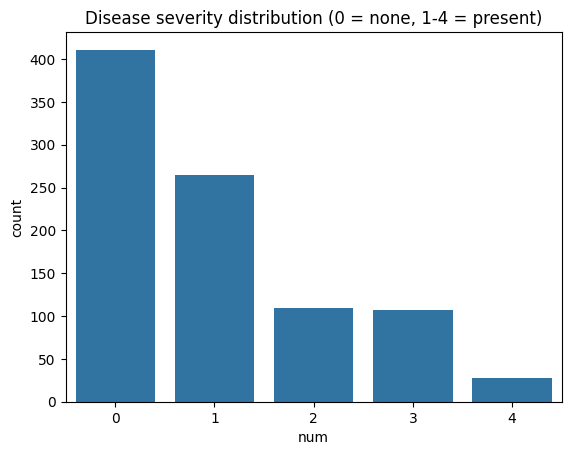

In [26]:
sns.countplot(x='num', data=df)
plt.title('Disease severity distribution (0 = none, 1-4 = present)')
plt.show()


In [27]:
missing_by_source = df.groupby('dataset')[['ca','slope','thal']].apply(lambda x: x.isnull().mean().round(2))
print(missing_by_source)

                 ca  slope  thal
dataset                         
Cleveland      0.02   0.00  0.01
Hungary        0.99   0.65  0.90
Switzerland    0.96   0.14  0.42
VA Long Beach  0.99   0.51  0.83


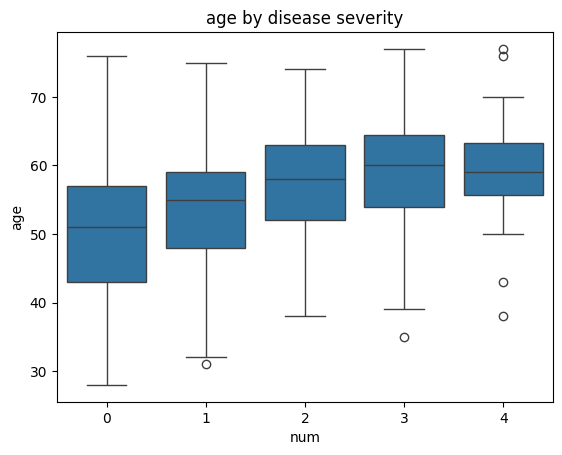

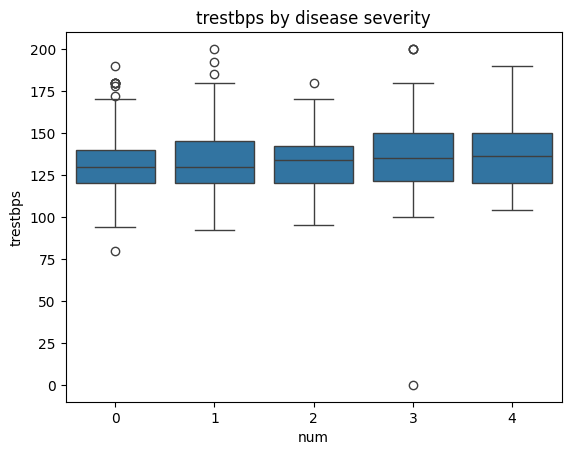

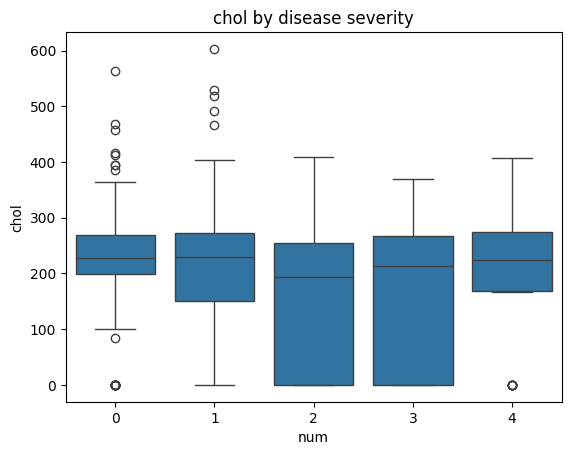

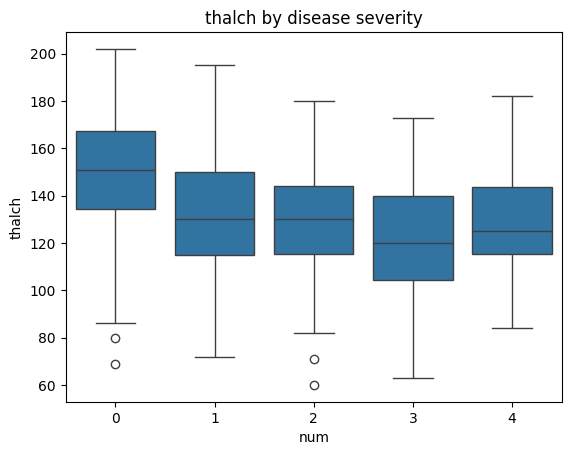

In [28]:
for col in ['age', 'trestbps', 'chol', 'thalch']:
    sns.boxplot(x='num', y=col, data=df)
    plt.title(f'{col} by disease severity')
    plt.show()

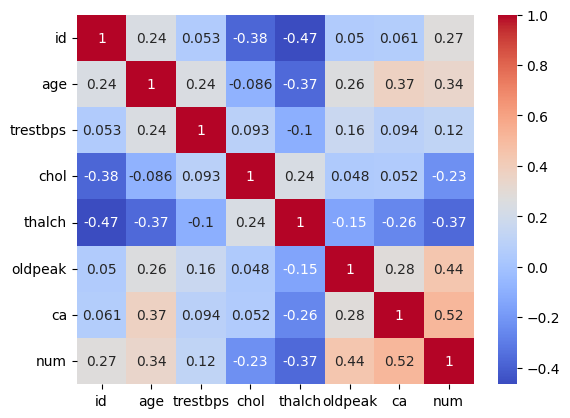

In [29]:
numeric_cols = df.select_dtypes(include='number').columns
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.show()